In [8]:
from dataclasses import dataclass
from functools import wraps
from pathlib import Path

import pandas as pd
from ultralytics import YOLO



In [9]:
@dataclass
class EvaluationConfig:
    weights: Path = Path("weights/best.pt")
    data: Path = Path("dataset/data.yaml")
    imgsz: int = 640
    conf: float = 0.25
    split: str = "val"


def to_dataframe(func):
    @wraps(func)
    def wrapper(*args, **kwargs):
        df = pd.DataFrame([func(*args, **kwargs)])
        display(df)
        return df
    return wrapper


class BirdModelEvaluator:
    def __init__(self, config):
        self.config = config
        self.model = YOLO(str(config.weights))

    @to_dataframe
    def evaluate(self):
        r = self.model.val(
            data=str(self.config.data),
            imgsz=self.config.imgsz,
            conf=self.config.conf,
            split=self.config.split,
            verbose=False
        )

        p, rec = float(r.box.mp), float(r.box.mr)
        f1 = 2 * p * rec / (p + rec) if p + rec else 0

        return {
            "Model": self.config.weights.name,
            "Split": self.config.split,
            "Precision": round(p, 4),
            "Recall": round(rec, 4),
            "F1": round(f1, 4),
            "mAP@50": round(float(r.box.map50), 4),
            "mAP@50-95": round(float(r.box.map), 4)
        }


In [10]:


config = EvaluationConfig()
df_metrics = BirdModelEvaluator(config).evaluate()

Ultralytics 8.4.150 🚀 Python-3.12.3 torch-2.14.0+cu130 CPU (Intel Core i5-9300H 2.40GHz)


/home/bogdan-khavroniuk/Desktop/bird-detector/venv/lib/python3.12/site-packages/torch/cuda/__init__.py:1174: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()
/home/bogdan-khavroniuk/Desktop/bird-detector/venv/lib/python3.12/site-packages/torch/cuda/__init__.py:1232: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  r = torch._C._cuda_getDeviceCount() if nvml_count < 0 else nvml_count


YOLO26n summary (fused): 120 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 192.4±45.4 MB/s, size: 125.9 KB)
val: Scanning /home/bogdan-khavroniuk/Desktop/bird-detector/dataset/labels/val.cache... 190 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 190/190 56.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 1.3it/s 9.5s0.9s
                   all        190        413      0.819        0.8       0.81      0.664
Speed: 1.5ms preprocess, 40.7ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /home/bogdan-khavroniuk/Desktop/bird-detector/runs/detect/val-2


,Model,Split,Precision,Recall,F1,mAP@50,mAP@50-95
0,best.pt,val,0.819,0.7997,0.8092,0.8096,0.6643


Frame read: True


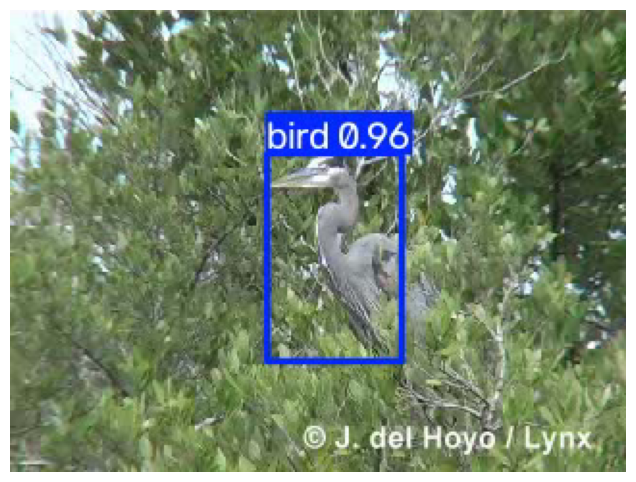

In [20]:
import cv2
import matplotlib.pyplot as plt

path = "examples/annotated_Great_Blue_Heron_00001.mp4"

cap = cv2.VideoCapture(path)
ret, frame = cap.read()
cap.release()

print("Frame read:", ret)

if ret:
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 6))
    plt.imshow(frame)
    plt.axis("off");

In [19]:
import cv2

path = "examples/annotated_Great_Blue_Heron_00001.mp4"

cap = cv2.VideoCapture(path)

print("Opened:", cap.isOpened())
print("Frames:", int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
print("Width:", int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)))
print("Height:", int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))
print("FPS:", cap.get(cv2.CAP_PROP_FPS))


Opened: True
Frames: 939
Width: 320
Height: 240
FPS: 30.0
